# Лабораторна робота 8. Побудова дерев ухвалення рішень

### Дисципліна: Розпізнавання образів та комп'ютерний зір
### Група: КІ-22-1
### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

## 1. Розглянути наведені вище приклади.
## 2. Реалізувати алгоритм побудови класифікаційного дерева ухвалення рішень, наведений в роботі, для свого варіанта, обгрунтувавши знаення відповідних параметрів.
## 3. Дати відповіді на контрольні запитання.
## 4. Відправити результати роботи у файлі lab_8_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

## Варіант індивідульного завдання

Варіант 9:
<br> x_train_9:
<br> [[37 46]
<br>  [26 50]
<br>  [23  6]
<br>  [21 33]
<br>  [36 42]
<br>  [37 44]
<br>  [19  6]
<br>  [23  5]
<br>  [35 28]]
<br> y_train_9:
<br> [ 1 -1  1  1 -1  1 -1  1  1]

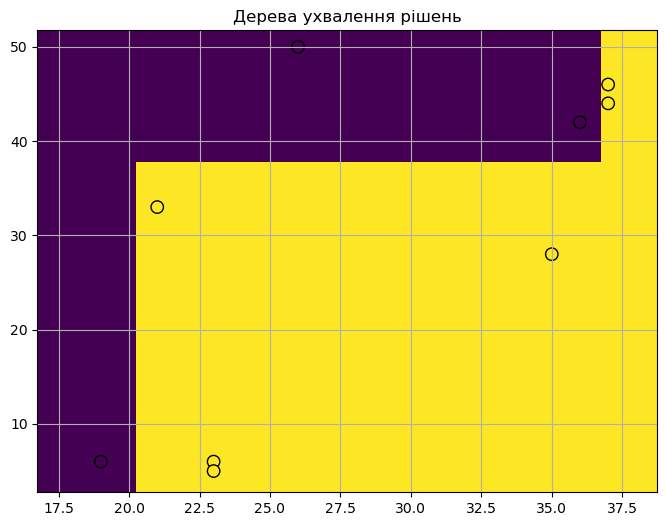

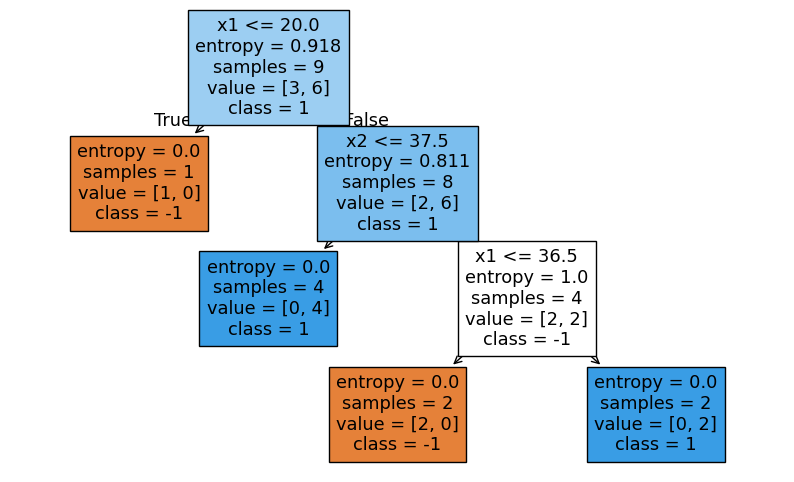

Predicted: [ 1 -1  1  1 -1  1 -1  1  1]
Accuracy: 1.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = np.array([
 [37,46],[26,50],[23,6],[21,33],[36,42],
 [37,44],[19,6],[23,5],[35,28]
])

y = np.array([1,-1,1,1,-1,1,-1,1,1])

def get_grid(data):
    x_min, x_max = data[:, 0].min() - 2, data[:, 0].max() + 2
    y_min, y_max = data[:, 1].min() - 2, data[:, 1].max() + 2
    return np.meshgrid(np.arange(x_min, x_max, 0.5),
                       np.arange(y_min, y_max, 0.5))

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X, y)

xx, yy = get_grid(X)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.pcolormesh(xx, yy, Z, shading='auto')

plt.scatter(X[:,0], X[:,1], c=y, edgecolors='black', s=80)

plt.title("Дерева ухвалення рішень")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plot_tree(clf, filled=True, feature_names=["x1","x2"], class_names=["-1","1"])
plt.show()

y_pred = clf.predict(X)
accuracy = np.mean(y_pred == y)

print("Predicted:", y_pred)
print("Accuracy:", accuracy)

## Контрольні питання

## 1. Які особливості дискретного випадку в логічних методах класифікації?
У логічних методах (дерева рішень, правила) дискретні ознаки обробляються через перевірку на рівність або приналежність до множини:
- Використовуються предикати вигляду $[x_j = v]$ або $[x_j \in \{v_1, v_2\}]$.
- Кількість можливих розгалужень у вузлі дерева відповідає кількості категорій (або бінарному розщепленню).
## 2. Які властивості характерні для неперервного випадку в логічних методах класифікації?
Для неперервних (числових) ознак алгоритми шукають оптимальний поріг (threshold) $t$:
- Предикат має вигляд $[x_j \le t]$.
- Алгоритм сортує значення ознаки та перевіряє всі можливі точки розрізу, щоб знайти ту, що найкраще розділяє класи.
## 3. Які критерії якості використовуються для побудови дерев ухвалення рішень?
Щоб обрати найкращу ознаку для розщеплення вузла, використовують:
1. Ентропія (Entropy): Міра хаосу. Ми шукаємо розщеплення, яке найбільше зменшує ентропію (Information Gain).
2. Індекс Джині (Gini Impurity): Ймовірність помилки при випадковій класифікації. Розрахунково швидший за ентропію.
3. Помилка класифікації (Misclassification Error): Рідше використовується для побудови, частіше для оцінки.
## 4. Як працює алгоритм ID3 у контексті побудови дерев класифікації?
ID3 (Iterative Dichotomiser 3) — це класичний алгоритм побудови дерева «зверху вниз»:
1. Обчислює ентропію для поточного набору даних.
2. Для кожної ознаки обчислює Information Gain (приріст інформації).
3. Обирає ознаку з найбільшим IG і створює вузол.
4. Рекурсивно повторює процес для кожної гілки, поки не досягне чистоти класі або не закінчаться ознаки.